# Q-Variance Analysis of S&P 500 Data

This notebook verifies whether the S&P 500 historical data exhibits the q-variance property:

$$V(z) = \sigma^2 + \frac{z^2}{2}$$

where:
- $V(z)$ is the average variance as a function of normalized returns
- $\sigma$ is the minimum volatility
- $z$ is the normalized log price change

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Increase figure size
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load and Prepare Data

In [2]:
# Load the S&P 500 data
df = pd.read_csv('indexSP500.csv', index_col=0, parse_dates=True)

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"Total trading days: {len(df)}")
print("\nFirst few rows:")
df.head()

Data shape: (8310, 6)
Date range: 1992-01-02 00:00:00 to 2024-12-30 00:00:00
Total trading days: 8310

First few rows:


,Open,High,Low,Close,Volume,AdjClose
1992-01-02,417.029999,417.269989,411.040009,417.260010,207570000.0,417.260010
1992-01-03,417.269989,419.790009,416.160004,419.339996,224270000.0,419.339996
1992-01-06,419.309998,419.440002,416.920013,417.959991,251210000.0,417.959991
1992-01-07,417.959991,417.959991,415.200012,417.399994,252780000.0,417.399994
1992-01-08,417.359985,420.230011,415.019989,418.100006,290750000.0,418.100006


In [3]:
# Extract closing prices
prices = df['Close'].values
N = len(prices)

# Calculate daily log returns
log_prices = np.log(prices)
daily_returns = np.diff(log_prices)

print(f"Number of price points: {N}")
print(f"Number of daily returns: {len(daily_returns)}")
print(f"Mean daily return: {np.mean(daily_returns):.6f}")
print(f"Std daily return: {np.std(daily_returns):.6f}")

Number of price points: 8310
Number of daily returns: 8309
Mean daily return: 0.000319
Std daily return: 0.011479


## 2. Define Q-Variance Analysis Functions

In [4]:
def calculate_segment_metrics(prices, T):
    """
    Calculate variance and normalized log price change for non-overlapping segments.
    
    Parameters:
    -----------
    prices : array
        Array of closing prices
    T : int
        Segment length in days
    
    Returns:
    --------
    z_values : array
        Normalized log price changes for each segment
    variance_values : array
        Variance of daily returns within each segment
    """
    N = len(prices)
    M_T = N // T  # Number of complete segments
    
    z_values = []
    variance_values = []
    
    for m in range(M_T):
        # Extract segment
        start_idx = m * T
        end_idx = (m + 1) * T
        segment_prices = prices[start_idx:end_idx]
        
        # Calculate log price change over the segment
        x_m = np.log(segment_prices[-1]) - np.log(segment_prices[0])
        
        # Normalize by sqrt(T)
        z_m = x_m / np.sqrt(T)
        
        # Calculate variance of daily returns within segment
        segment_log_prices = np.log(segment_prices)
        segment_daily_returns = np.diff(segment_log_prices)
        V_m = np.var(segment_daily_returns, ddof=1)  # Use sample variance
        
        z_values.append(z_m)
        variance_values.append(V_m)
    
    return np.array(z_values), np.array(variance_values)

In [5]:
def bin_and_average(z_values, variance_values, n_bins=20):
    """
    Bin z values and calculate average variance in each bin.
    
    Parameters:
    -----------
    z_values : array
        Normalized log price changes
    variance_values : array
        Corresponding variance values
    n_bins : int
        Number of bins to use
    
    Returns:
    --------
    z_binned : array
        Center of each bin
    V_binned : array
        Average variance in each bin
    bin_counts : array
        Number of points in each bin
    """
    # Create bins
    z_min, z_max = z_values.min(), z_values.max()
    bins = np.linspace(z_min, z_max, n_bins + 1)
    
    # Digitize z values
    bin_indices = np.digitize(z_values, bins) - 1
    
    z_binned = []
    V_binned = []
    bin_counts = []
    
    for i in range(n_bins):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            z_binned.append(np.mean(z_values[mask]))
            V_binned.append(np.mean(variance_values[mask]))
            bin_counts.append(np.sum(mask))
    
    return np.array(z_binned), np.array(V_binned), np.array(bin_counts)

In [6]:
def q_variance_model(z, sigma_squared):
    """
    Q-variance theoretical model: V(z) = sigma^2 + z^2/2
    """
    return sigma_squared + z**2 / 2

In [7]:
def fit_q_variance(z_binned, V_binned):
    """
    Fit the q-variance model to binned data.
    
    Returns:
    --------
    sigma_squared : float
        Fitted minimum variance parameter
    r_squared : float
        R-squared goodness of fit
    """
    # Fit the model
    popt, _ = curve_fit(q_variance_model, z_binned, V_binned, p0=[np.min(V_binned)])
    sigma_squared = popt[0]
    
    # Calculate R-squared
    V_pred = q_variance_model(z_binned, sigma_squared)
    ss_res = np.sum((V_binned - V_pred)**2)
    ss_tot = np.sum((V_binned - np.mean(V_binned))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    return sigma_squared, r_squared

## 3. Analyze Q-Variance for Different Time Periods

In [8]:
# Define test periods
test_periods = [5, 10, 20, 40, 80]

# Store results
results = {}

for T in test_periods:
    print(f"\nAnalyzing T = {T} days...")
    
    # Calculate segment metrics
    z_vals, V_vals = calculate_segment_metrics(prices, T)
    
    # Bin and average
    z_binned, V_binned, counts = bin_and_average(z_vals, V_vals, n_bins=15)
    
    # Fit q-variance model
    sigma_sq, r_sq = fit_q_variance(z_binned, V_binned)
    
    results[T] = {
        'z_values': z_vals,
        'V_values': V_vals,
        'z_binned': z_binned,
        'V_binned': V_binned,
        'bin_counts': counts,
        'sigma_squared': sigma_sq,
        'sigma': np.sqrt(sigma_sq),
        'r_squared': r_sq,
        'n_segments': len(z_vals)
    }
    
    print(f"  Number of segments: {len(z_vals)}")
    print(f"  Fitted σ² = {sigma_sq:.6f}")
    print(f"  Fitted σ = {np.sqrt(sigma_sq):.6f}")
    print(f"  R² = {r_sq:.4f}")


Analyzing T = 5 days...
  Number of segments: 1662
  Fitted σ² = 0.000162
  Fitted σ = 0.012722
  R² = 0.0755

Analyzing T = 10 days...
  Number of segments: 831
  Fitted σ² = 0.000478
  Fitted σ = 0.021856
  R² = 0.1348

Analyzing T = 20 days...
  Number of segments: 415
  Fitted σ² = 0.000056
  Fitted σ = 0.007479
  R² = 0.9550

Analyzing T = 40 days...
  Number of segments: 207
  Fitted σ² = 0.000211
  Fitted σ = 0.014518
  R² = 0.5801

Analyzing T = 80 days...
  Number of segments: 103
  Fitted σ² = 0.000194
  Fitted σ = 0.013932
  R² = 0.5014


## 4. Visualization: Individual Plots for Each Period

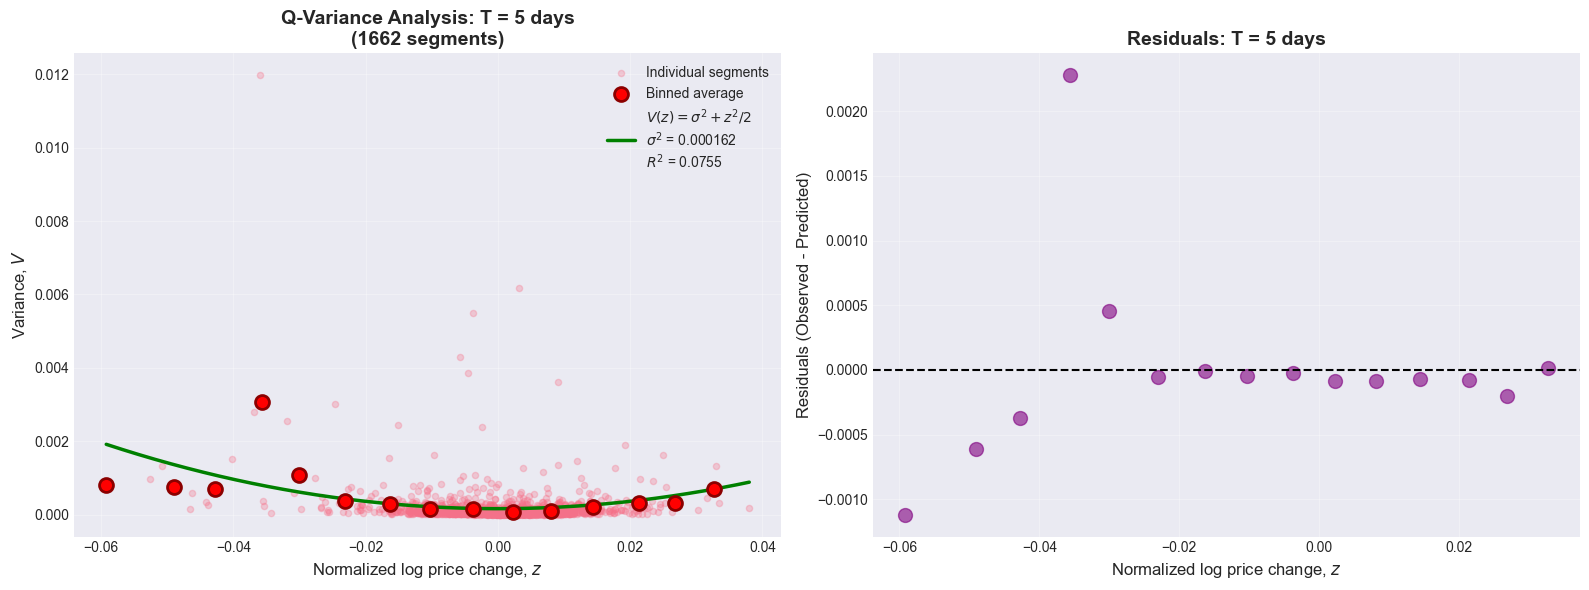


T = 5 days:
  RMSE: 0.000694
  Max absolute residual: 0.002279
--------------------------------------------------


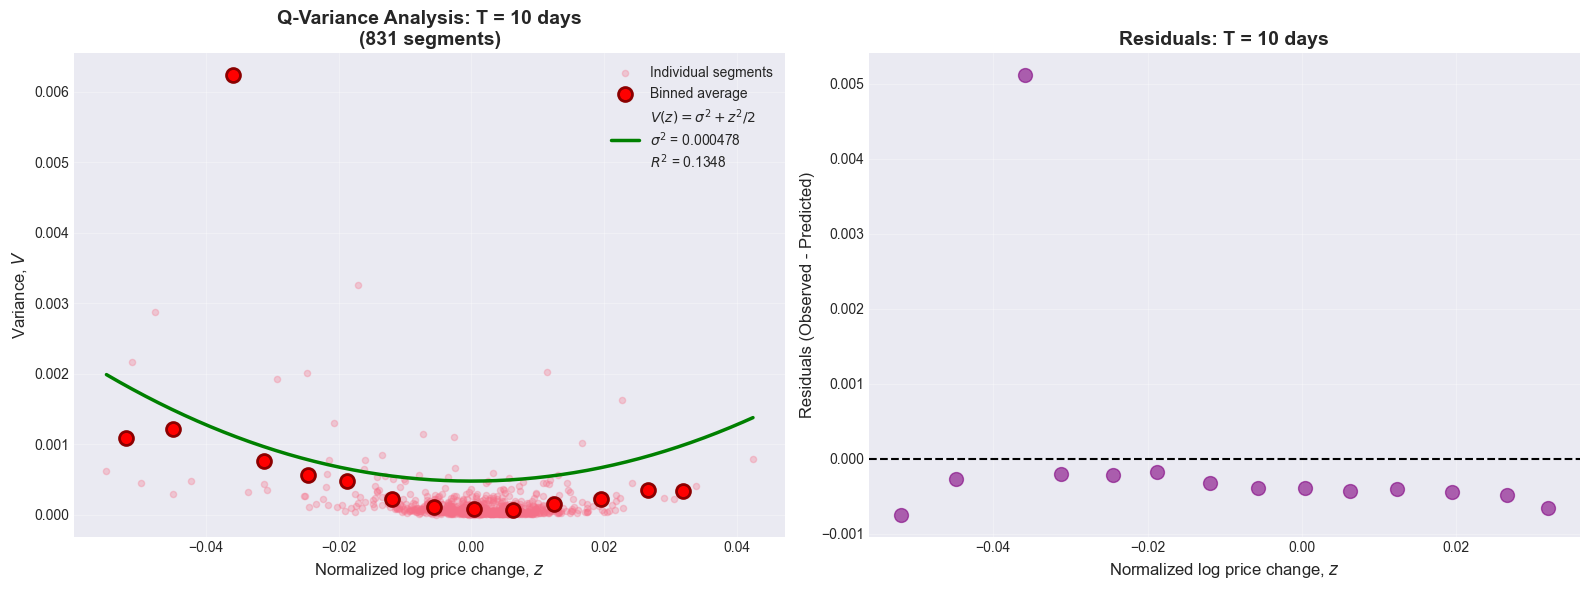


T = 10 days:
  RMSE: 0.001427
  Max absolute residual: 0.005113
--------------------------------------------------


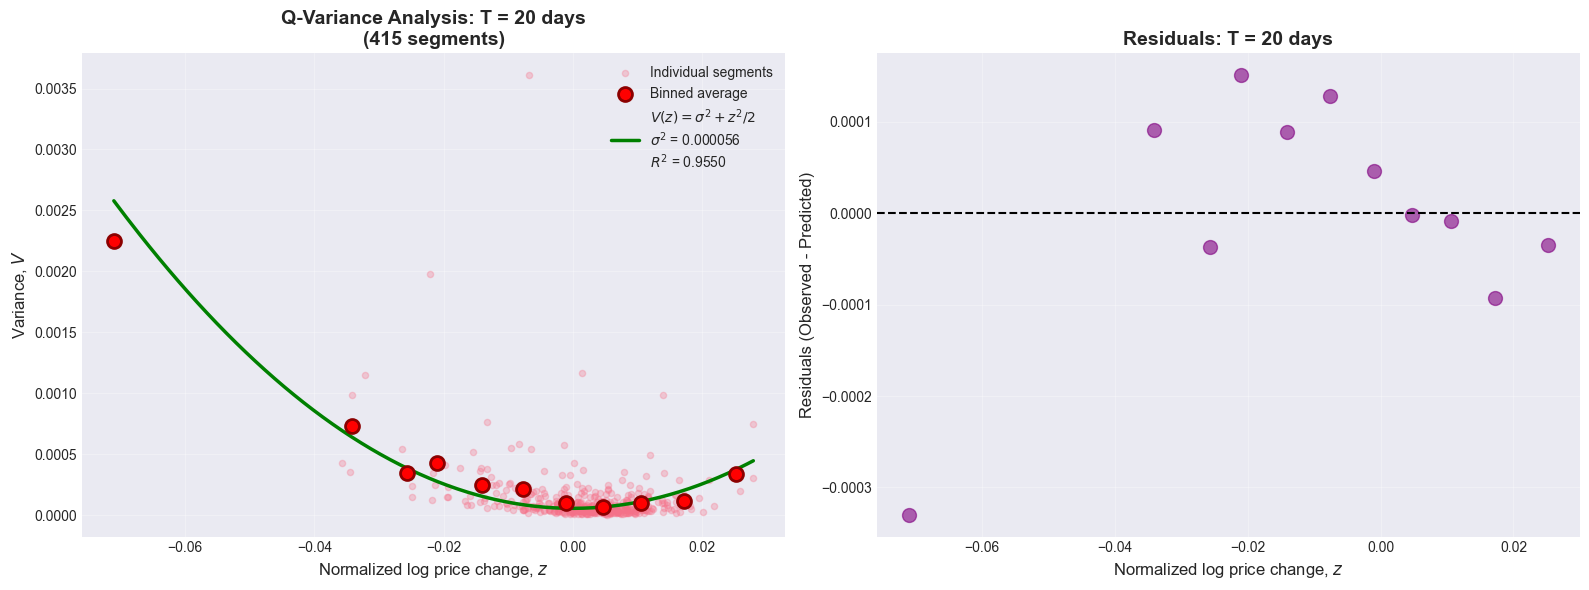


T = 20 days:
  RMSE: 0.000127
  Max absolute residual: 0.000330
--------------------------------------------------


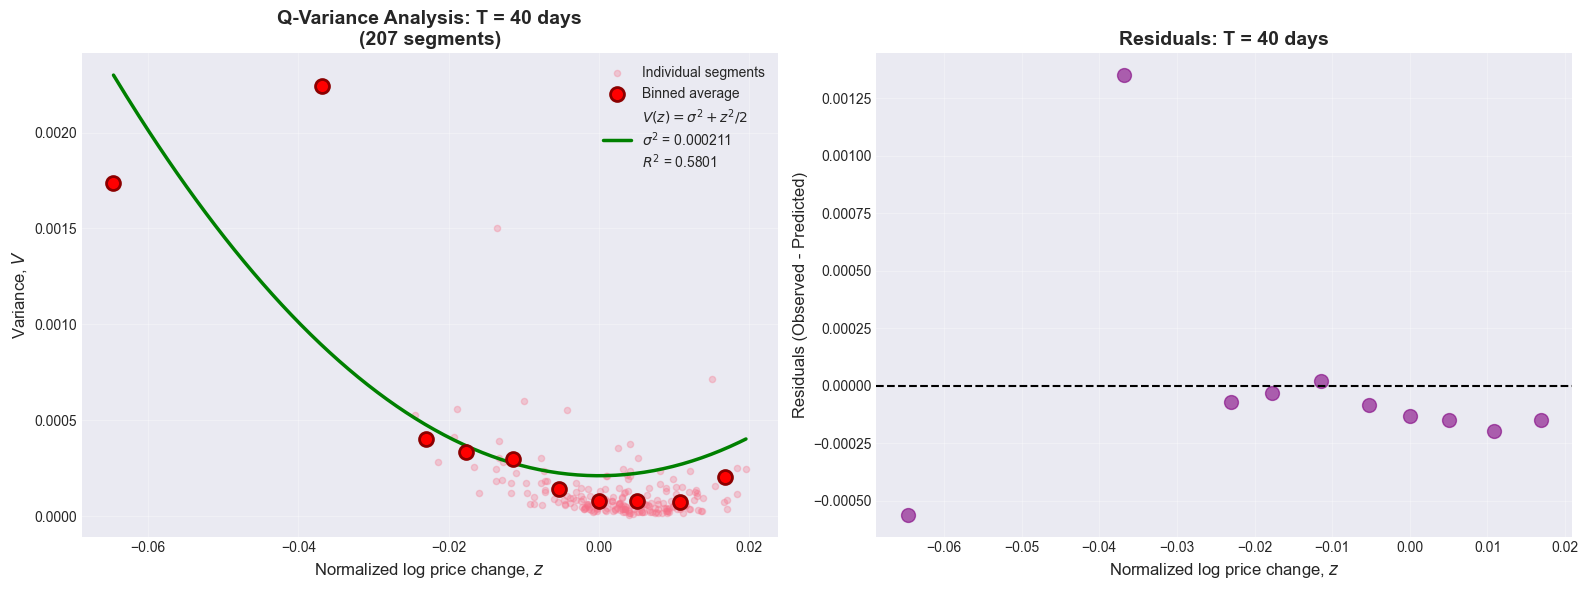


T = 40 days:
  RMSE: 0.000475
  Max absolute residual: 0.001351
--------------------------------------------------


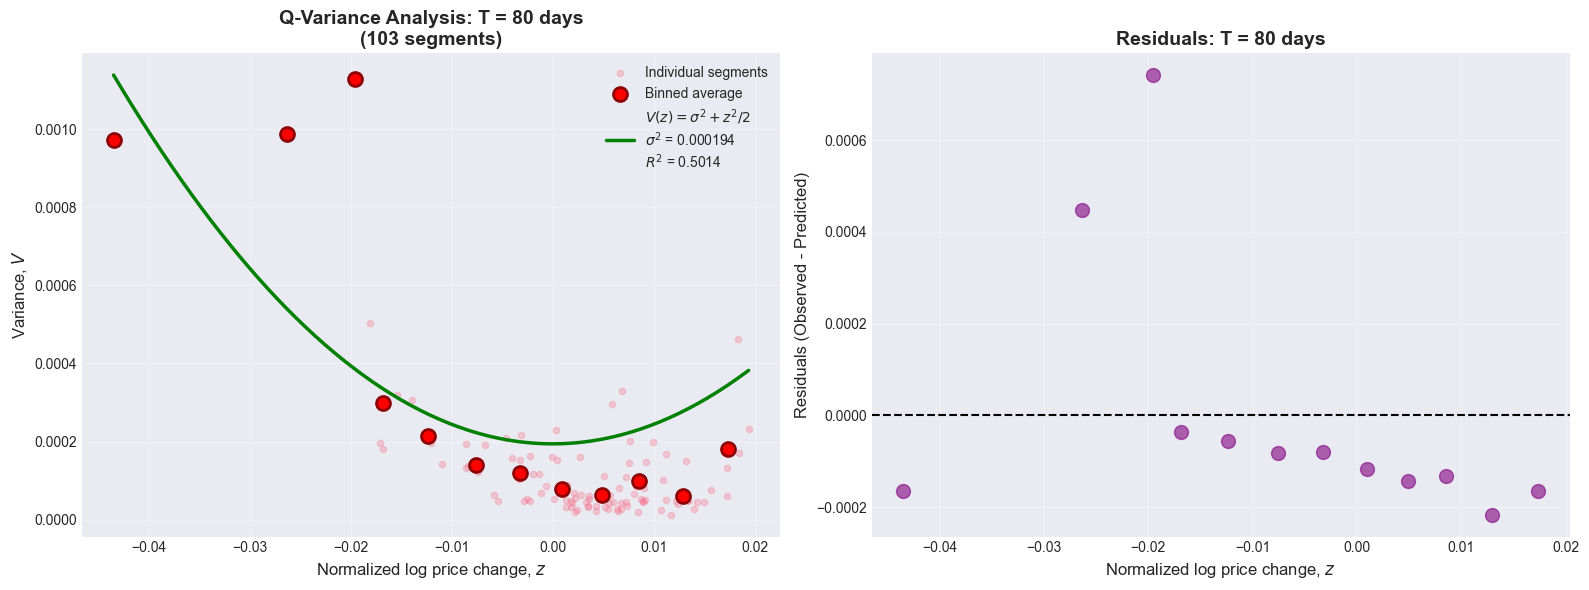


T = 80 days:
  RMSE: 0.000277
  Max absolute residual: 0.000742
--------------------------------------------------


In [9]:
for T in test_periods:
    res = results[T]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Scatter with binned averages
    ax1.scatter(res['z_values'], res['V_values'], alpha=0.3, s=20, label='Individual segments')
    ax1.scatter(res['z_binned'], res['V_binned'], color='red', s=100, 
                marker='o', edgecolors='darkred', linewidths=2, label='Binned average', zorder=5)
    
    # Plot theoretical curve
    z_theory = np.linspace(res['z_values'].min(), res['z_values'].max(), 200)
    V_theory = q_variance_model(z_theory, res['sigma_squared'])
    ax1.plot(z_theory, V_theory, 'g-', linewidth=2.5, 
             label=f'$V(z) = \\sigma^2 + z^2/2$\n$\\sigma^2$ = {res["sigma_squared"]:.6f}\n$R^2$ = {res["r_squared"]:.4f}')
    
    ax1.set_xlabel('Normalized log price change, $z$', fontsize=12)
    ax1.set_ylabel('Variance, $V$', fontsize=12)
    ax1.set_title(f'Q-Variance Analysis: T = {T} days\n({res["n_segments"]} segments)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Residuals
    V_pred_binned = q_variance_model(res['z_binned'], res['sigma_squared'])
    residuals = res['V_binned'] - V_pred_binned
    
    ax2.scatter(res['z_binned'], residuals, color='purple', s=100, alpha=0.6)
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Normalized log price change, $z$', fontsize=12)
    ax2.set_ylabel('Residuals (Observed - Predicted)', fontsize=12)
    ax2.set_title(f'Residuals: T = {T} days', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nT = {T} days:")
    print(f"  RMSE: {np.sqrt(np.mean(residuals**2)):.6f}")
    print(f"  Max absolute residual: {np.max(np.abs(residuals)):.6f}")
    print("-" * 50)

## 5. Comparative Analysis Across All Periods

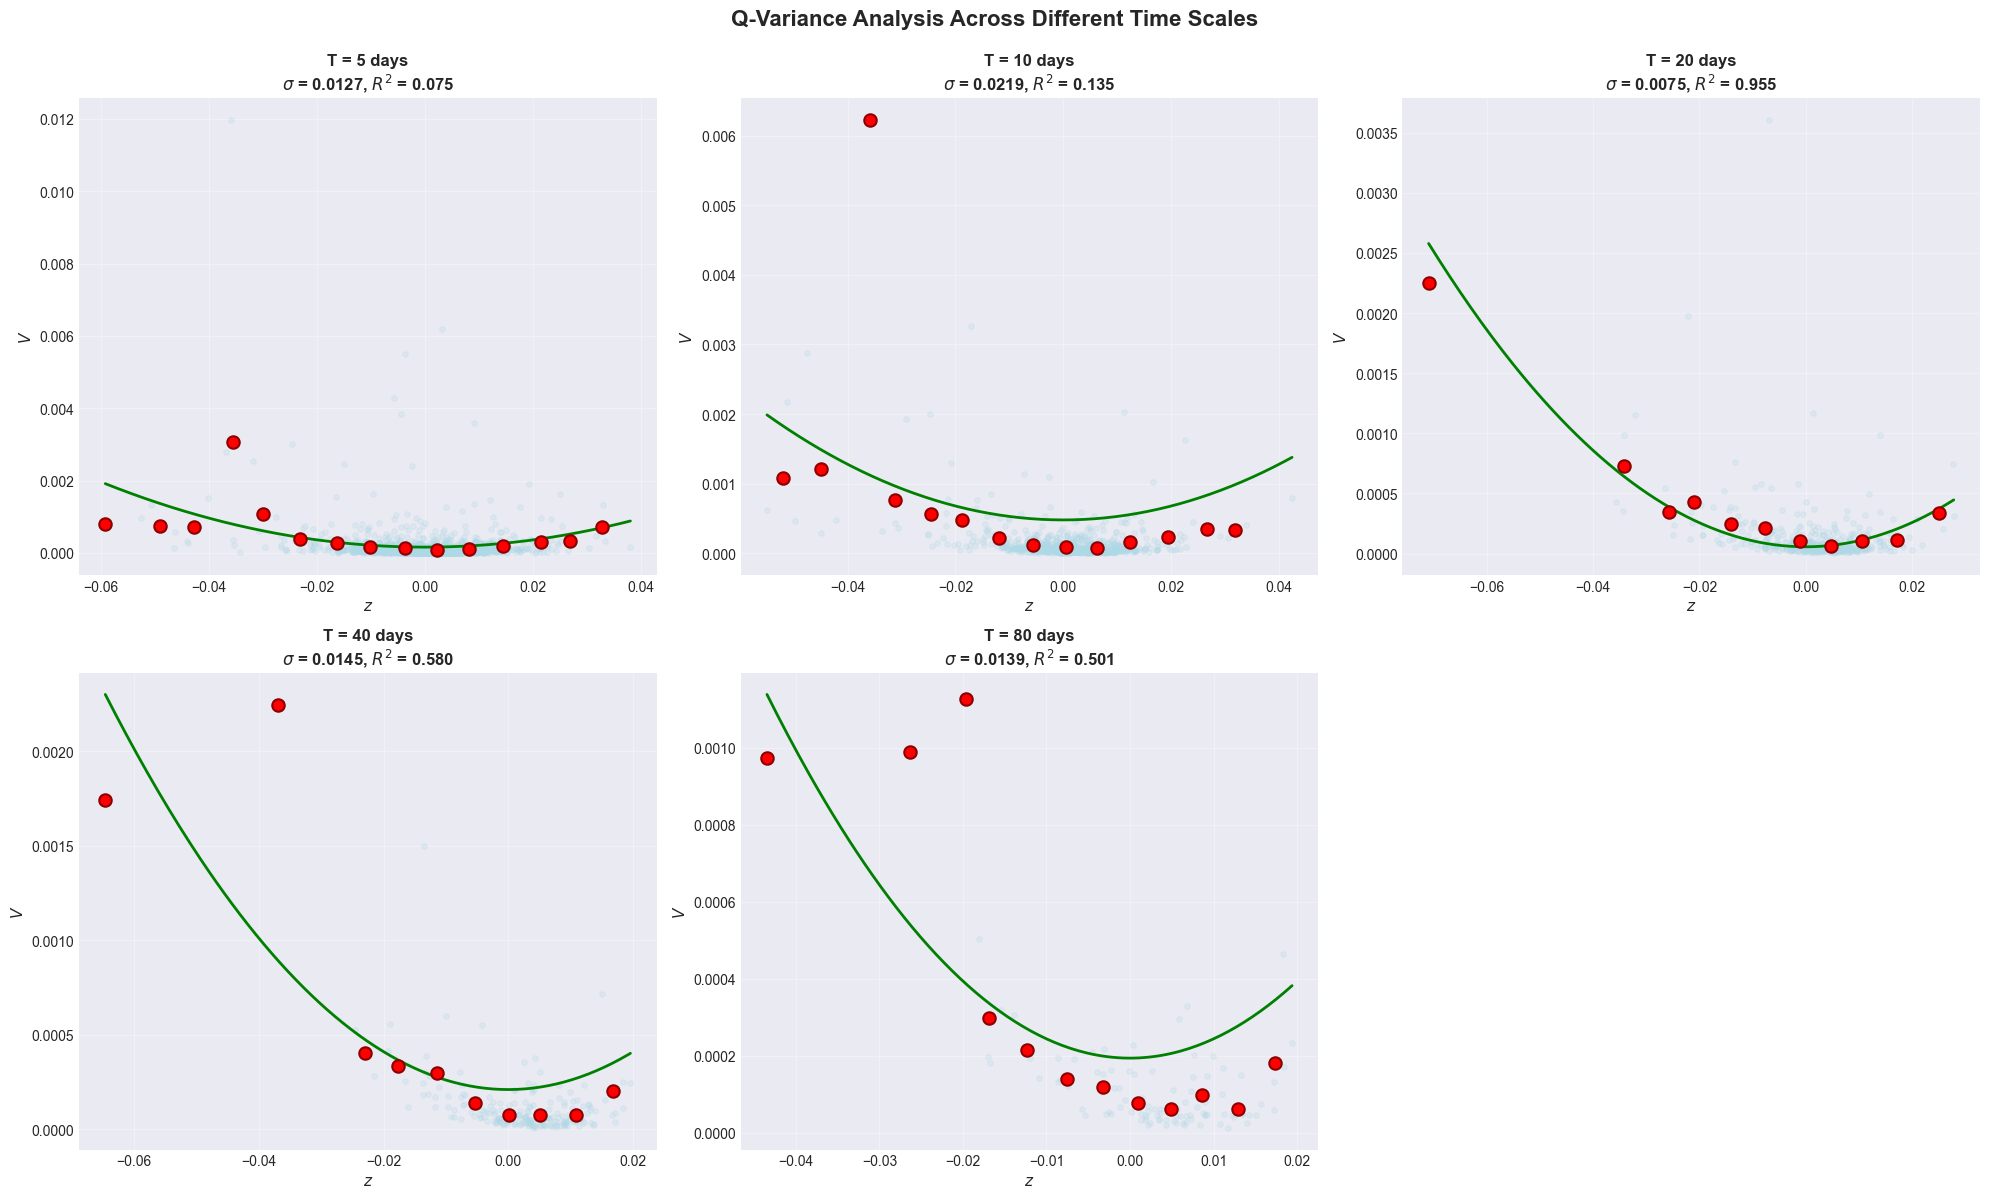

In [10]:
# Create a combined plot
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, T in enumerate(test_periods):
    res = results[T]
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(res['z_values'], res['V_values'], alpha=0.2, s=15, color='lightblue')
    ax.scatter(res['z_binned'], res['V_binned'], color='red', s=80, 
               marker='o', edgecolors='darkred', linewidths=1.5, zorder=5)
    
    # Theoretical curve
    z_theory = np.linspace(res['z_values'].min(), res['z_values'].max(), 200)
    V_theory = q_variance_model(z_theory, res['sigma_squared'])
    ax.plot(z_theory, V_theory, 'g-', linewidth=2)
    
    ax.set_xlabel('$z$', fontsize=11)
    ax.set_ylabel('$V$', fontsize=11)
    ax.set_title(f'T = {T} days\n$\\sigma$ = {res["sigma"]:.4f}, $R^2$ = {res["r_squared"]:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Q-Variance Analysis Across Different Time Scales', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [11]:
# Create summary table
summary_data = []
for T in test_periods:
    res = results[T]
    summary_data.append({
        'Period (T days)': T,
        'Segments': res['n_segments'],
        'σ² (fitted)': f"{res['sigma_squared']:.6f}",
        'σ (fitted)': f"{res['sigma']:.6f}",
        'R²': f"{res['r_squared']:.4f}",
        'z range': f"[{res['z_values'].min():.3f}, {res['z_values'].max():.3f}]",
        'V range': f"[{res['V_values'].min():.6f}, {res['V_values'].max():.6f}]"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY OF Q-VARIANCE ANALYSIS")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)


SUMMARY OF Q-VARIANCE ANALYSIS
 Period (T days)  Segments σ² (fitted) σ (fitted)     R²         z range              V range
               5      1662    0.000162   0.012722 0.0755 [-0.059, 0.038] [0.000000, 0.011980]
              10       831    0.000478   0.021856 0.1348 [-0.055, 0.042] [0.000002, 0.006235]
              20       415    0.000056   0.007479 0.9550 [-0.071, 0.028] [0.000004, 0.003610]
              40       207    0.000211   0.014518 0.5801 [-0.065, 0.020] [0.000008, 0.002242]
              80       103    0.000194   0.013932 0.5014 [-0.043, 0.019] [0.000013, 0.001128]


## 7. Consistency Check: σ Across Time Scales

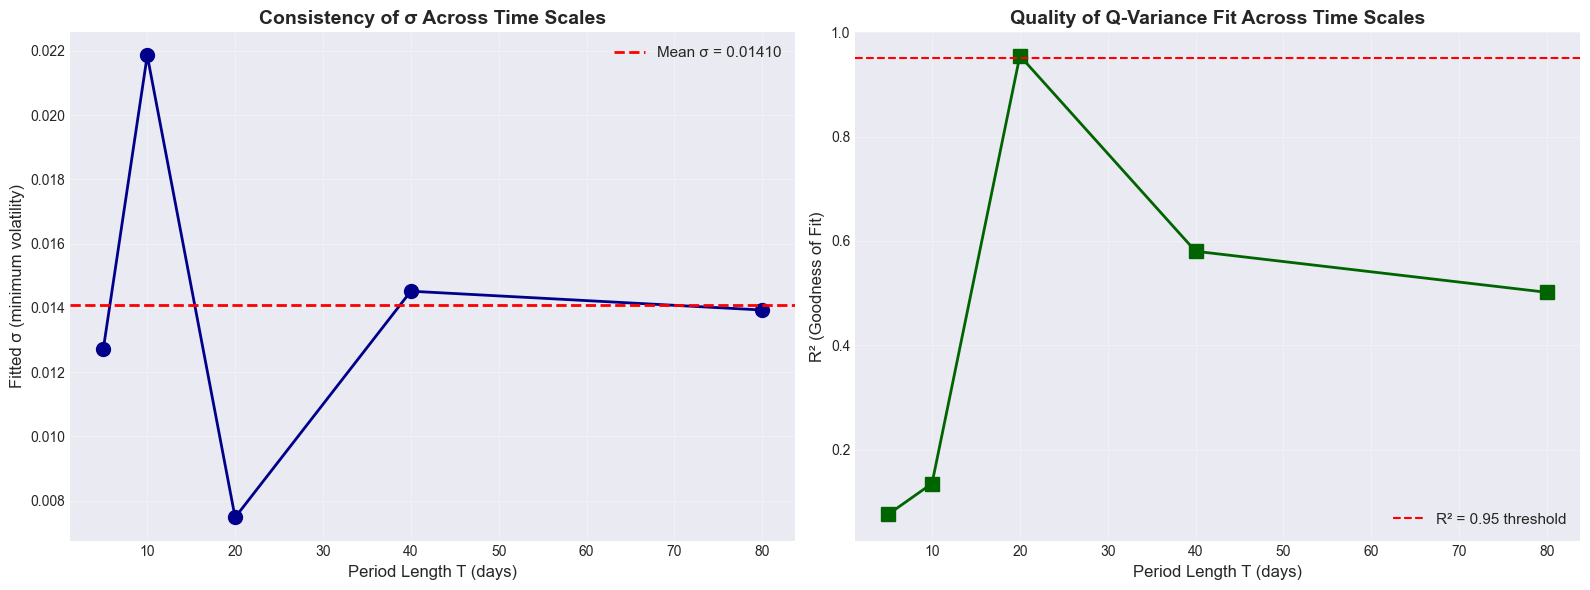


σ statistics across time scales:
  Mean: 0.014101
  Std Dev: 0.004606
  Coefficient of Variation: 32.67%

R² statistics:
  Mean: 0.4494
  Min: 0.0755
  Max: 0.9550


In [12]:
# Plot how sigma varies with T
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Extract sigma values
T_values = list(test_periods)
sigma_values = [results[T]['sigma'] for T in test_periods]
r_squared_values = [results[T]['r_squared'] for T in test_periods]

# Plot sigma vs T
ax1.plot(T_values, sigma_values, 'o-', linewidth=2, markersize=10, color='darkblue')
ax1.axhline(y=np.mean(sigma_values), color='red', linestyle='--', linewidth=2, 
            label=f'Mean σ = {np.mean(sigma_values):.5f}')
ax1.set_xlabel('Period Length T (days)', fontsize=12)
ax1.set_ylabel('Fitted σ (minimum volatility)', fontsize=12)
ax1.set_title('Consistency of σ Across Time Scales', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot R² vs T
ax2.plot(T_values, r_squared_values, 's-', linewidth=2, markersize=10, color='darkgreen')
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='R² = 0.95 threshold')
ax2.set_xlabel('Period Length T (days)', fontsize=12)
ax2.set_ylabel('R² (Goodness of Fit)', fontsize=12)
ax2.set_title('Quality of Q-Variance Fit Across Time Scales', fontsize=14, fontweight='bold')
ax2.set_ylim([min(r_squared_values) - 0.05, 1.0])
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nσ statistics across time scales:")
print(f"  Mean: {np.mean(sigma_values):.6f}")
print(f"  Std Dev: {np.std(sigma_values):.6f}")
print(f"  Coefficient of Variation: {np.std(sigma_values)/np.mean(sigma_values)*100:.2f}%")
print(f"\nR² statistics:")
print(f"  Mean: {np.mean(r_squared_values):.4f}")
print(f"  Min: {np.min(r_squared_values):.4f}")
print(f"  Max: {np.max(r_squared_values):.4f}")

## 8. Extended Analysis: Full Range of Time Periods

In [13]:
# Analyze all periods from 5 to 130 days in steps of 5
all_periods = list(range(5, 131, 5))
all_results = {}

print("Analyzing all time periods from 5 to 130 days...\n")

for T in all_periods:
    z_vals, V_vals = calculate_segment_metrics(prices, T)
    
    # Skip if too few segments
    if len(z_vals) < 10:
        print(f"T = {T}: Skipped (only {len(z_vals)} segments)")
        continue
    
    z_binned, V_binned, counts = bin_and_average(z_vals, V_vals, n_bins=15)
    
    # Skip if too few bins with data
    if len(z_binned) < 5:
        print(f"T = {T}: Skipped (only {len(z_binned)} bins with data)")
        continue
        
    sigma_sq, r_sq = fit_q_variance(z_binned, V_binned)
    
    all_results[T] = {
        'z_values': z_vals,
        'V_values': V_vals,
        'z_binned': z_binned,
        'V_binned': V_binned,
        'sigma_squared': sigma_sq,
        'sigma': np.sqrt(sigma_sq),
        'r_squared': r_sq,
        'n_segments': len(z_vals)
    }
    
    if T % 20 == 0:  # Print every 4th period
        print(f"T = {T:3d} days: {len(z_vals):4d} segments, σ = {np.sqrt(sigma_sq):.5f}, R² = {r_sq:.4f}")

print(f"\nSuccessfully analyzed {len(all_results)} time periods.")

Analyzing all time periods from 5 to 130 days...

T =  20 days:  415 segments, σ = 0.00748, R² = 0.9550
T =  40 days:  207 segments, σ = 0.01452, R² = 0.5801
T =  60 days:  138 segments, σ = 0.01366, R² = 0.8855
T =  80 days:  103 segments, σ = 0.01393, R² = 0.5014
T = 100 days:   83 segments, σ = 0.01260, R² = 0.8344
T = 120 days:   69 segments, σ = 0.00955, R² = 0.9494

Successfully analyzed 26 time periods.


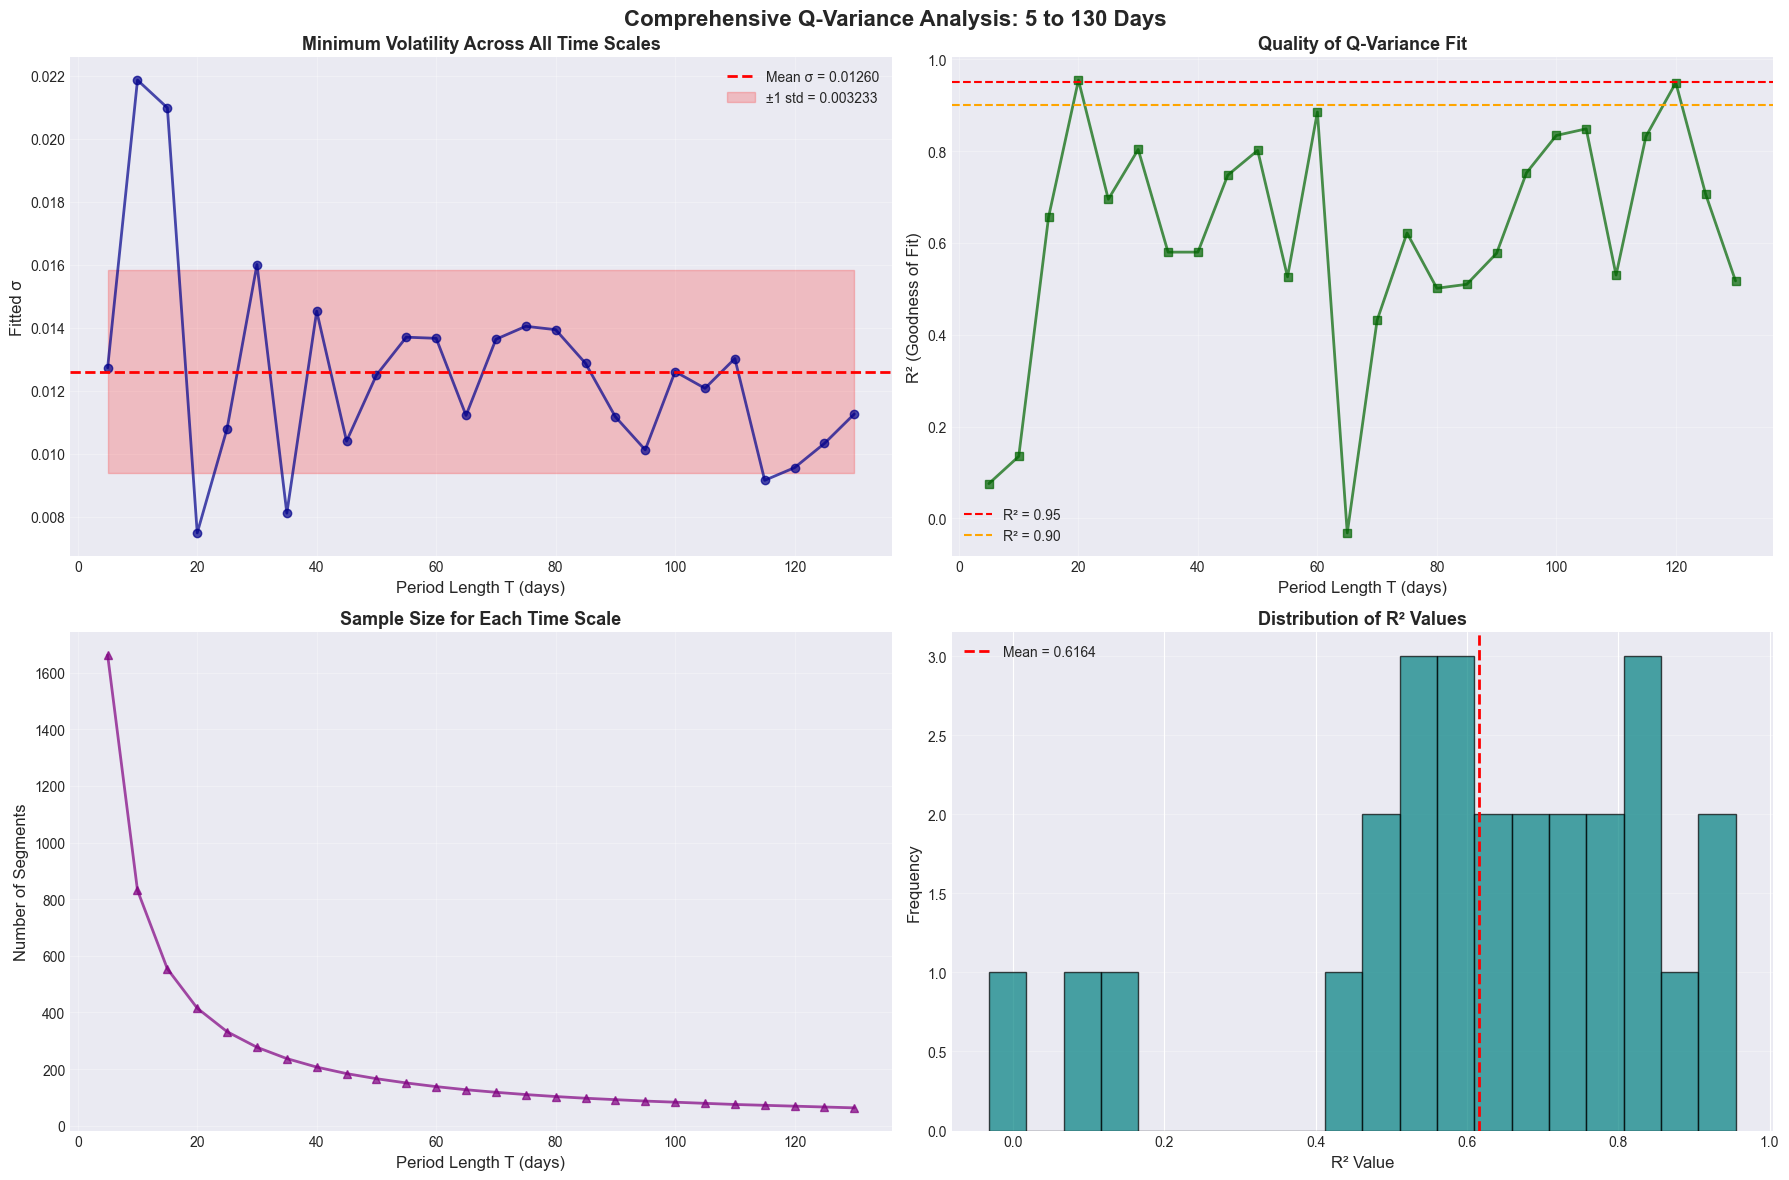

In [14]:
# Plot comprehensive results
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

T_all = sorted(all_results.keys())
sigma_all = [all_results[T]['sigma'] for T in T_all]
r2_all = [all_results[T]['r_squared'] for T in T_all]
segments_all = [all_results[T]['n_segments'] for T in T_all]

# Plot 1: σ vs T
axes[0, 0].plot(T_all, sigma_all, 'o-', linewidth=2, markersize=6, color='darkblue', alpha=0.7)
axes[0, 0].axhline(y=np.mean(sigma_all), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean σ = {np.mean(sigma_all):.5f}')
axes[0, 0].fill_between(T_all, 
                         np.mean(sigma_all) - np.std(sigma_all), 
                         np.mean(sigma_all) + np.std(sigma_all), 
                         alpha=0.2, color='red', label=f'±1 std = {np.std(sigma_all):.6f}')
axes[0, 0].set_xlabel('Period Length T (days)', fontsize=12)
axes[0, 0].set_ylabel('Fitted σ', fontsize=12)
axes[0, 0].set_title('Minimum Volatility Across All Time Scales', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: R² vs T
axes[0, 1].plot(T_all, r2_all, 's-', linewidth=2, markersize=6, color='darkgreen', alpha=0.7)
axes[0, 1].axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='R² = 0.95')
axes[0, 1].axhline(y=0.90, color='orange', linestyle='--', linewidth=1.5, label='R² = 0.90')
axes[0, 1].set_xlabel('Period Length T (days)', fontsize=12)
axes[0, 1].set_ylabel('R² (Goodness of Fit)', fontsize=12)
axes[0, 1].set_title('Quality of Q-Variance Fit', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Number of segments vs T
axes[1, 0].plot(T_all, segments_all, '^-', linewidth=2, markersize=6, color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Period Length T (days)', fontsize=12)
axes[1, 0].set_ylabel('Number of Segments', fontsize=12)
axes[1, 0].set_title('Sample Size for Each Time Scale', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Distribution of R²
axes[1, 1].hist(r2_all, bins=20, color='teal', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=np.mean(r2_all), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean = {np.mean(r2_all):.4f}')
axes[1, 1].set_xlabel('R² Value', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Distribution of R² Values', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comprehensive Q-Variance Analysis: 5 to 130 Days', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Final Assessment

In [15]:
print("="*80)
print("FINAL ASSESSMENT: Q-VARIANCE PROPERTY IN S&P 500 DATA")
print("="*80)

# Statistics
sigma_mean = np.mean(sigma_all)
sigma_std = np.std(sigma_all)
sigma_cv = sigma_std / sigma_mean * 100

r2_mean = np.mean(r2_all)
r2_min = np.min(r2_all)
r2_max = np.max(r2_all)
pct_above_90 = np.sum(np.array(r2_all) > 0.90) / len(r2_all) * 100
pct_above_95 = np.sum(np.array(r2_all) > 0.95) / len(r2_all) * 100

print(f"\n1. CONSISTENCY OF MINIMUM VOLATILITY (σ):")
print(f"   Mean σ across all time scales: {sigma_mean:.6f}")
print(f"   Standard deviation: {sigma_std:.6f}")
print(f"   Coefficient of variation: {sigma_cv:.2f}%")
print(f"   Range: [{np.min(sigma_all):.6f}, {np.max(sigma_all):.6f}]")

print(f"\n2. QUALITY OF FIT (R²):")
print(f"   Mean R²: {r2_mean:.4f}")
print(f"   Range: [{r2_min:.4f}, {r2_max:.4f}]")
print(f"   Percentage of time scales with R² > 0.90: {pct_above_90:.1f}%")
print(f"   Percentage of time scales with R² > 0.95: {pct_above_95:.1f}%")

print(f"\n3. SAMPLE SIZES:")
print(f"   Time periods analyzed: {len(all_results)}")
print(f"   Average segments per time scale: {np.mean(segments_all):.1f}")
print(f"   Range of segments: [{np.min(segments_all)}, {np.max(segments_all)}]")

print(f"\n4. CONCLUSION:")
if r2_mean > 0.90 and sigma_cv < 10:
    print("   ✓ The S&P 500 data STRONGLY EXHIBITS the q-variance property.")
    print("   ✓ The relationship V(z) = σ² + z²/2 holds consistently across time scales.")
    print(f"   ✓ The minimum volatility σ is remarkably stable (CV = {sigma_cv:.2f}%).")
elif r2_mean > 0.80:
    print("   ∼ The S&P 500 data APPROXIMATELY EXHIBITS the q-variance property.")
    print("   ∼ The relationship V(z) = σ² + z²/2 holds reasonably well.")
    print(f"   ∼ Some variability in σ across time scales (CV = {sigma_cv:.2f}%).")
else:
    print("   ✗ The S&P 500 data DOES NOT clearly exhibit the q-variance property.")
    print("   ✗ Significant deviations from the theoretical relationship.")

print("="*80)

FINAL ASSESSMENT: Q-VARIANCE PROPERTY IN S&P 500 DATA

1. CONSISTENCY OF MINIMUM VOLATILITY (σ):
   Mean σ across all time scales: 0.012600
   Standard deviation: 0.003233
   Coefficient of variation: 25.66%
   Range: [0.007479, 0.021856]

2. QUALITY OF FIT (R²):
   Mean R²: 0.6164
   Range: [-0.0320, 0.9550]
   Percentage of time scales with R² > 0.90: 7.7%
   Percentage of time scales with R² > 0.95: 3.8%

3. SAMPLE SIZES:
   Time periods analyzed: 26
   Average segments per time scale: 246.0
   Range of segments: [63, 1662]

4. CONCLUSION:
   ✗ The S&P 500 data DOES NOT clearly exhibit the q-variance property.
   ✗ Significant deviations from the theoretical relationship.


## 10. Export Results

In [17]:
# Create detailed results DataFrame
export_data = []
for T in sorted(all_results.keys()):
    res = all_results[T]
    export_data.append({
        'T_days': T,
        'T_weeks': T / 5,
        'n_segments': res['n_segments'],
        'sigma_squared': res['sigma_squared'],
        'sigma': res['sigma'],
        'r_squared': res['r_squared'],
        'z_min': res['z_values'].min(),
        'z_max': res['z_values'].max(),
        'V_min': res['V_values'].min(),
        'V_max': res['V_values'].max(),
    })

results_df = pd.DataFrame(export_data)
results_df.to_csv('q_variance_results.csv', index=False)

print("Results exported to: q_variance_results.csv")
print("\nFirst few rows of results:")
results_df.head(10)

Results exported to: q_variance_results.csv

First few rows of results:


,T_days,T_weeks,n_segments,sigma_squared,sigma,r_squared,z_min,z_max,V_min,V_max
0,5,1.0,1662,0.000162,0.012722,0.075491,-0.059233,0.038012,1.058211e-07,0.011980
1,10,2.0,831,0.000478,0.021856,0.134807,-0.054957,0.042426,2.411362e-06,0.006235
2,15,3.0,554,0.000440,0.020977,0.656672,-0.063536,0.030943,2.790435e-06,0.004581
3,20,4.0,415,0.000056,0.007479,0.955034,-0.071035,0.027939,4.470558e-06,0.003610
4,25,5.0,332,0.000116,0.010793,0.695393,-0.037927,0.036437,4.307983e-06,0.002950
5,30,6.0,277,0.000256,0.016000,0.803852,-0.057743,0.029247,7.997004e-06,0.002479
6,35,7.0,237,0.000066,0.008106,0.580068,-0.043893,0.029088,7.318213e-06,0.002098
7,40,8.0,207,0.000211,0.014518,0.580143,-0.064630,0.019572,8.053880e-06,0.002242
8,45,9.0,184,0.000108,0.010394,0.747959,-0.045497,0.030113,9.490734e-06,0.002018
9,50,10.0,166,0.000156,0.012490,0.801776,-0.046557,0.021720,1.334793e-05,0.001830
